In [1]:
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


#loading initial imputs and outputs 
X= np.load('../data/initial_data/function_1/initial_inputs.npy')
y = np.load('../data/initial_data/function_1/initial_outputs.npy')

#checking shape of data 
print('Inputs Shape:', X.shape)
print('Outputs Shape:', y.shape)

#creating a dataframe 
df=pd.DataFrame(X, columns=['x1', 'x2'])
df['y']=y

#checking DataFrame
df.head(10)




Inputs Shape: (10, 2)
Outputs Shape: (10,)


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


In [2]:
# new row from BO server
new_row = pd.DataFrame([{'x1': 0.93, 'x2': 0.83, 'y': -1.58e-92}, {'x1': 0.04, 'x2': 0.69, 'y': 1.36e-152}, {'x1': 0.12, 'x2': 0.97, 'y': 1.377837E-262}, {
        'x1': 0.69,
        'x2': 0.02,
        'y': 1.8647707194978913e-163
    }, {
        'x1': 0.99,
        'x2': 0.01,
        'y': 0.0
    }, {
        'x1': 0.59,
        'x2': 0.13,
        'y': 9.44e-80
    } ]  # second new row
)

# append using concat
df = pd.concat([df, new_row], ignore_index=True)

df.tail()   # check it worked
# rebuild arrays from the updated dataframe
X = df[['x1', 'x2']].to_numpy()
y = df['y'].to_numpy()

print("Inputs Shape:", X.shape)
print("Outputs Shape:", y.shape)


Inputs Shape: (16, 2)
Outputs Shape: (16,)


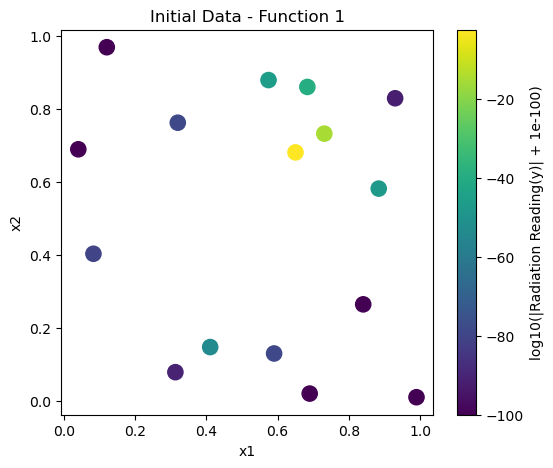

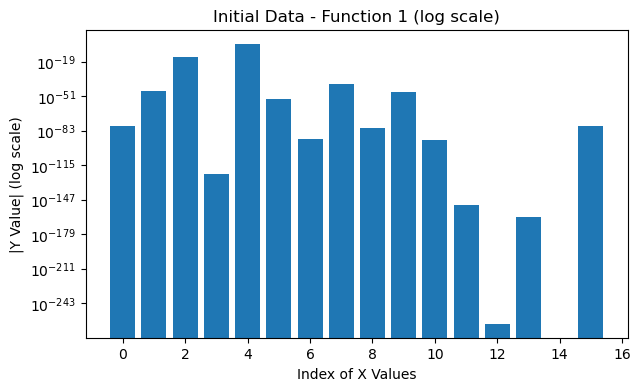

In [3]:
#visualise the data 
plt.figure(figsize=(6,5))
scatter = plt.scatter(df['x1'], df['x2'], c=np.log10(np.abs(df['y'])+ 1e-100), s=120, cmap='viridis')
plt.colorbar(scatter, label='log10(|Radiation Reading(y)| + 1e-100)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Initial Data - Function 1')
plt.show()

plt.figure(figsize=(7,4))
plt.bar(range(len(df)), np.abs(df['y']))
plt.yscale('log')
plt.xlabel('Index of X Values')
plt.ylabel('|Y Value| (log scale)')
plt.title('Initial Data - Function 1 (log scale)')
plt.show()


In [4]:
#setting parameters and making 2D grid 
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF,ConstantKernel, WhiteKernel

#scaling y becuase it spans different orders of mangnitude 
# Option A (default): z-score
y_fit = (y - np.mean(y)) / (np.std(y) + 1e-12)

# Option B (if y spans many orders of magnitude): signed log
#y_fit = np.sign(y) * np.log1p(np.abs(y))

#hyperparamters for GP surrogate model and acqusition function 
rbf_lengthscale = 0.1
noise_assumption = 1e-3
beta = 5.8

#building a 2D grid to represent the test space 
#linspace(start, stop, num)
g = np.linspace(0.0, 1.0, 101)   
x1g, x2g = np.meshgrid(g, g)
X_grid = np.column_stack([x1g.ravel(), x2g.ravel()])

In [5]:
#fit the gp to current data 
kernel = (ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.1,length_scale_bounds=(1e-3,5)) + WhiteKernel(noise_level=1e-3 , noise_level_bounds=(1e-6, 1)))
# To allow kernel to operate on the right scale for tiny numbers 
gp = GaussianProcessRegressor(kernel = kernel, alpha = noise_assumption, normalize_y = True, random_state = 0)
gp.fit(X, y_fit)

GaussianProcessRegressor(alpha=0.001,
                         kernel=1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.001),
                         normalize_y=True, random_state=0)

In [6]:
#compute acquisition UCB on the grid 
#posterior mean and std 
mu, std = gp.predict(X_grid, return_std = True)
#std = np.maximum(std, 1e-12)

#UCB acquistion 
ucb= mu + beta * std


In [9]:
#choose next query point 
# --- Minimum-distance safeguard ---
# Grid spacing is 0.01, so 0.05 ≈ 5 grid steps
min_dist = 0.05

# Compute distance from each grid point to nearest observed point
dists = np.sqrt(
    ((X_grid[:, None, :] - X[None, :, :]) ** 2).sum(axis=2)
)  # shape: (N_grid, N_obs)

min_dists = dists.min(axis=1)

# Only exclude points that are genuinely near-duplicates
mask = min_dists >= min_dist

# Fallback: relax constraint slightly if mask is too restrictive
if not np.any(mask):
    mask = min_dists >= 0.03

# --- Select next query point ---
idx = np.argmax(ucb[mask])
x_next = X_grid[mask][idx]

print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f})")

#ix = int(np.argmax(ucb))
#x_next = X_grid[ix]
#print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f})")

x_next = (0.000000, 0.140000)


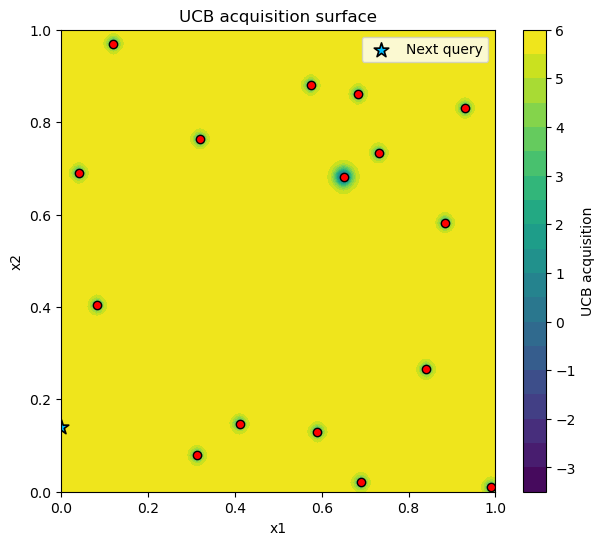

In [11]:
acq = mu + beta * std
plt.figure(figsize=(7,6))
cs = plt.contourf(x1g, x2g, acq.reshape(x1g.shape), levels=20, cmap='viridis')
plt.colorbar(label='UCB acquisition')
plt.scatter(X[:,0], X[:,1], c='red', edgecolors='k')
plt.xlabel('x1'); plt.ylabel('x2'); plt.title('UCB acquisition surface')
# highlight next query point on your UCB surface
plt.scatter(x_next[0], x_next[1], 
            c='deepskyblue', s=120, marker='*', 
            edgecolors='k', linewidth=1.2, label='Next query')

plt.legend()
plt.show()


In [12]:
#x_next check 
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

y_best = float(np.max(y))
model        = gp
X_candidates = np.array(X_grid)   # shape (n_candidates, n_dims)
acq_values   = np.array(ucb)   # shape (n_candidates,)
x_next       = np.array(x_next)   # shape (n_dims,)
y_best       = y_best
X_sampled    = np.array(X)   # all evaluated X so far


def _percentile_of_score(values, score):
    """Simple percentile rank: percentage of values <= score."""
    values = np.asarray(values).ravel()
    return float(100.0 * (np.sum(values <= score) / max(len(values), 1)))

def _first_length_scale_from_kernel(kernel):
    """Extract effective GP length-scale (handles RBF, Matern, etc.)."""
    if hasattr(kernel, "length_scale"):
        ls = getattr(kernel, "length_scale")
        try:
            ls = float(np.mean(ls))
        except Exception:
            ls = float(ls)
        return ls
    for attr in ("k1", "k2"):
        if hasattr(kernel, attr):
            ls = _first_length_scale_from_kernel(getattr(kernel, attr))
            if ls is not None:
                return ls
    return None

def _nearest_dist_over_ell(x_next, X_sampled, ell):
    """Compute distance from x_next to nearest sampled point ÷ ell."""
    x_next = np.asarray(x_next, dtype=float).reshape(1, -1)
    X_sampled = np.asarray(X_sampled, dtype=float)
    if X_sampled.size == 0:
        return np.nan
    dists = euclidean_distances(x_next, X_sampled).ravel()
    d_min = float(np.min(dists))
    if (ell is None) or (ell <= 0):
        return np.nan
    return d_min / ell

def _classify_strategy(sig_pct):
    """Assign strategy label from σ percentile (bounded exploration)."""
    if sig_pct <= 40:
        return "Exploit"
    elif sig_pct <= 75:
        return "Balanced"
    elif sig_pct <= 85:
        return "Explore"
    else:
        return "Too exploratory"

def sanity_check_table(model, X_candidates, acq_values, x_next, y_best, X_sampled):
    """
    Builds a 1-row DataFrame with:
      μ_raw (raw), σ_pct (scaled %), dist_over_ℓ_raw (raw), acq_pct (scaled %), Strategy
    """

    # Ensure arrays are the correct shape
    X_candidates = np.asarray(X_candidates, dtype=float)
    acq_values = np.asarray(acq_values, dtype=float).ravel()
    x_next = np.asarray(x_next, dtype=float).ravel()

    # 1) Predict μ, σ for all candidates (for percentiles) and for x_next
    mu_all, sigma_all = model.predict(X_candidates, return_std=True)
    mu_xn, sigma_xn = model.predict(x_next.reshape(1, -1), return_std=True)
    mu_xn = float(mu_xn.ravel()[0])
    sigma_xn = float(sigma_xn.ravel()[0])

    # 2) Percentiles for σ and acquisition
    sig_pct = _percentile_of_score(sigma_all, sigma_xn)

    # Find acquisition value at x_next by matching to nearest candidate
    idx_closest = np.argmin(np.sum((X_candidates - x_next.reshape(1, -1))**2, axis=1))
    acq_xn = float(acq_values[idx_closest])
    acq_pct = _percentile_of_score(acq_values, acq_xn)

    # 3) Distance / ell
    ell = None
    if hasattr(model, "kernel_"):
        ell = _first_length_scale_from_kernel(model.kernel_)
    dist_over_ell = _nearest_dist_over_ell(x_next, X_sampled, ell)

    # 4) Strategy classification
    strategy = _classify_strategy(sig_pct)

    # 5) Build the 1-row DataFrame (rounded for readability)
    data = {
        "μ_raw (raw)":            np.round(mu_xn, 3),
        "σ_pct (scaled %)":       int(np.round(sig_pct)),
        "dist_over_ℓ_raw (raw)":  np.round(dist_over_ell, 3) if np.isfinite(dist_over_ell) else np.nan,
        "acq_pct (scaled %)":     int(np.round(acq_pct)),
        "Strategy":               strategy
    }

    return pd.DataFrame([data])
   

result_df = sanity_check_table(model, X_candidates, acq_values, x_next, y_best, X_sampled)
result_df

,μ_raw (raw),σ_pct (scaled %),dist_over_ℓ_raw (raw),acq_pct (scaled %),Strategy
0,-0.0,100,16.841,47,Too exploratory
